#  Crop Yield Prediction — Machine Learning Project

**Author:** Laura Rodríguez
**Dataset:** FAO Crop Yield Dataset (Kaggle)  
**Goal:** Predict agricultural crop yield (hg/ha) using climate and farming variables.

---

##  Project Overview

This notebook walks through a complete data science workflow:

1. **Data Loading & Exploration** — understanding what the data looks like
2. **Exploratory Data Analysis (EDA)** — finding patterns with visualizations
3. **Data Preprocessing** — preparing data for machine learning
4. **Model Training & Comparison** — Linear Regression, Random Forest, XGBoost
5. **Model Evaluation** — measuring accuracy with RMSE and R²
6. **Feature Importance** — what variables matter most?

---

##  Section 1 — Import Libraries

We start by importing all the tools (libraries) we need.


In [1]:
# --- DATA HANDLING ---
import pandas as pd          # for working with tables
import numpy as np           # for mathematical operations

# --- VISUALIZATION ---
import matplotlib.pyplot as plt   # basic charts
import seaborn as sns             # nicer-looking statistical charts

# --- MACHINE LEARNING ---
from sklearn.model_selection import train_test_split    # split data into train/test
from sklearn.preprocessing import LabelEncoder          # convert text to numbers
from sklearn.linear_model import LinearRegression       # simple baseline model
from sklearn.ensemble import RandomForestRegressor      # powerful tree-based model
from sklearn.metrics import mean_squared_error, r2_score  # measure model accuracy
from xgboost import XGBRegressor                        # state-of-the-art model

# --- SETTINGS ---
import warnings
warnings.filterwarnings('ignore')   # hide unimportant warnings

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print(' All libraries imported successfully!')

 All libraries imported successfully!


---
##  Section 2 — Load & Explore the Data

We load `yield_df.csv` — the main dataset, already merged with rainfall, temperature and pesticide data.

The dataset contains **28,242 records** across **101 countries** and **10 crop types**, spanning from **1990 to 2013**.

In [2]:
# Load the dataset
# Make sure yield_df.csv is in the same folder as this notebook!
df = pd.read_csv('yield_df.csv')

# Drop the unnamed index column
df = df.drop(columns=['Unnamed: 0'])

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print()
df.head(10)

Dataset shape: 28242 rows x 7 columns



,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37
5,Albania,Wheat,1990,30197,1485.0,121.0,16.37
6,Albania,Maize,1991,29068,1485.0,121.0,15.36
7,Albania,Potatoes,1991,77818,1485.0,121.0,15.36
8,Albania,"Rice, paddy",1991,28538,1485.0,121.0,15.36
9,Albania,Sorghum,1991,6667,1485.0,121.0,15.36


In [3]:
# Summary of each column: data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB


In [4]:
# Statistical summary: mean, min, max, standard deviation
df.describe().round(2)

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.00,28242.00,28242.00,28242.00,28242.00
mean,2001.54,77053.33,1149.06,37076.91,20.54
std,7.05,84956.61,709.81,59958.78,6.31
min,1990.00,50.00,51.00,0.04,1.30
25%,1995.00,19919.25,593.00,1702.00,16.70
50%,2001.00,38295.00,1083.00,17529.44,21.51
75%,2008.00,104676.75,1668.00,48687.88,26.00
max,2013.00,501412.00,3240.00,367778.00,30.65


###  Data Summary — Key Observations

- **Yield** ranges from a minimum of **50 hg/ha** to a maximum of **501,412 hg/ha**, revealing an enormous gap between the least and most productive farming conditions globally.
- The **mean yield (77,053 hg/ha)** is roughly double the **median (38,295 hg/ha)** — a sign that the distribution is heavily right-skewed. A small number of very high-yielding crops (like potatoes) pull the average upward.
- **No missing values** are present in this dataset.
- The **standard deviation (84,957)** is larger than the mean itself, reflecting the natural diversity in yield across different crop types, climates, and farming technologies in 101 countries.

In [5]:
# Check for missing values and dataset scope
print('Missing values per column:')
print(df.isnull().sum())
print()
print(f'Total unique countries : {df["Area"].nunique()}')
print(f'Total unique crops     : {df["Item"].nunique()}')
print(f'Year range             : {df["Year"].min()} - {df["Year"].max()}')
print()
print('Crops in the dataset:')
print(df['Item'].unique())

Missing values per column:
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Total unique countries : 101
Total unique crops     : 10
Year range             : 1990 - 2013

Crops in the dataset:
['Maize' 'Potatoes' 'Rice, paddy' 'Sorghum' 'Soybeans' 'Wheat' 'Cassava'
 'Sweet potatoes' 'Plantains and others' 'Yams']


---
##  Section 3 — Exploratory Data Analysis (EDA)

EDA is about **understanding the data visually** before building any model.
We ask questions like: Which crop produces the most? Does temperature affect yield? How has productivity changed over time?

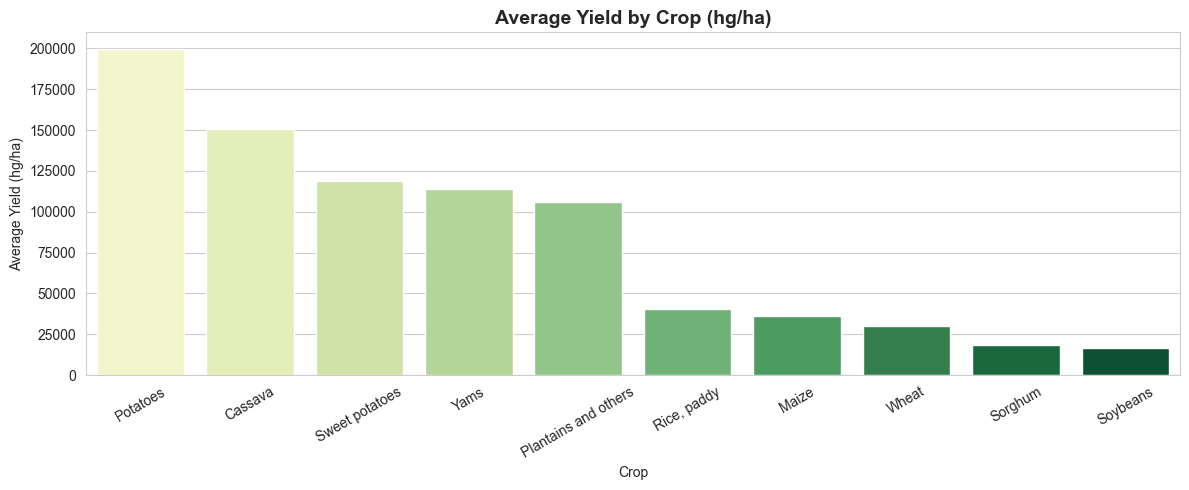

In [6]:
# --- CHART 1: Average yield by crop type ---
avg_yield = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=avg_yield.index, y=avg_yield.values, palette='YlGn')
plt.title('Average Yield by Crop (hg/ha)', fontsize=14, fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Average Yield (hg/ha)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

###  Analysis — Average Yield by Crop

There is a striking difference in productivity across crop types:

- **Potatoes (~199,802 hg/ha)** and **Cassava (~150,479 hg/ha)** are by far the highest-yielding crops. Both are root/tuber crops that produce large biomass per hectare and are widely cultivated in favorable climates.
- **Soybeans (~16,731 hg/ha)** and **Sorghum (~18,636 hg/ha)** sit at the bottom. Despite soybeans being a major global commodity, they are naturally lower-yielding per hectare compared to tubers.
- **Cereals** (Maize, Wheat, Rice) occupy the middle range — reflecting their importance as global staple crops even though their yield per hectare is moderate.

>  **Important note for modeling:** Because different crops have very different yield scales, `Crop Type` will be one of the most critical features for the model's accuracy.

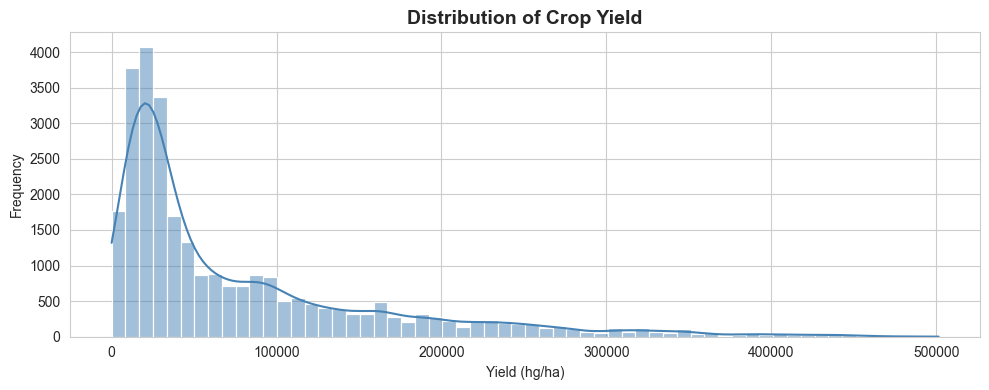

In [7]:
# --- CHART 2: Yield distribution ---
plt.figure(figsize=(10, 4))
sns.histplot(df['hg/ha_yield'], bins=60, color='steelblue', kde=True)
# kde=True adds a smooth density curve on top of the histogram
plt.title('Distribution of Crop Yield', fontsize=14, fontweight='bold')
plt.xlabel('Yield (hg/ha)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Analysis — Yield Distribution

The histogram reveals a strongly right-skewed distribution (skewness = 1.79) — most crops cluster at low-to-moderate yields, while a small number of extreme observations stretch the distribution to the right.

The peak frequency falls between **0 and 50,000 hg/ha**, where the majority of grain crops (wheat, maize, rice) concentrate. From there, frequency drops sharply, ending in a long tail that reaches up to ~500,000 hg/ha — driven by tuber crops like potatoes in Northern Europe.

This gap between the **median (38,295 hg/ha)** and the **mean (77,053 hg/ha)** is the statistical fingerprint of that skew: a handful of exceptionally high-yielding observations pull the mean upward, making it a poor representation of what a typical crop actually produces worldwide.

Tree-based models like Random Forest and XGBoost handle this skewness naturally, without requiring log-transformation of the target variable.

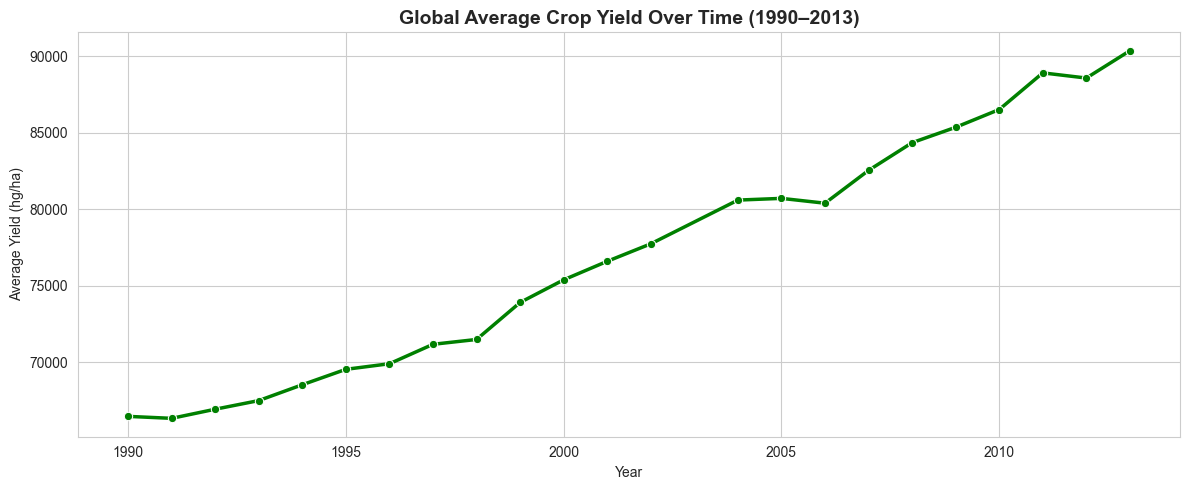

In [8]:
# --- CHART 3: Yield trend over time ---
yearly_yield = df.groupby('Year')['hg/ha_yield'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_yield, x='Year', y='hg/ha_yield', color='green', linewidth=2.5, marker='o')
plt.title('Global Average Crop Yield Over Time (1990–2013)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Yield (hg/ha)')
plt.tight_layout()
plt.show()

###  Analysis — Global Yield Trend Over Time

The line chart shows a **clear and consistent upward trend** in global average crop yield:

- From **1990 (~66,447 hg/ha)** to **2013 (~90,357 hg/ha)**, the global average increased by approximately **+36%** over 23 years.
-The growth is steady across the entire period, with no major disruptions or reversals.
-While the dataset does not directly measure technological factors such as improved seeds, irrigation systems, or mechanization, the variable pesticides_tonnes offers a partial indirect signal — higher pesticide use is generally associated with more industrialized and technologically advanced farming practices. 
Small year-to-year fluctuations are expected and likely reflect natural weather variability or differences in country-level data reporting across years.


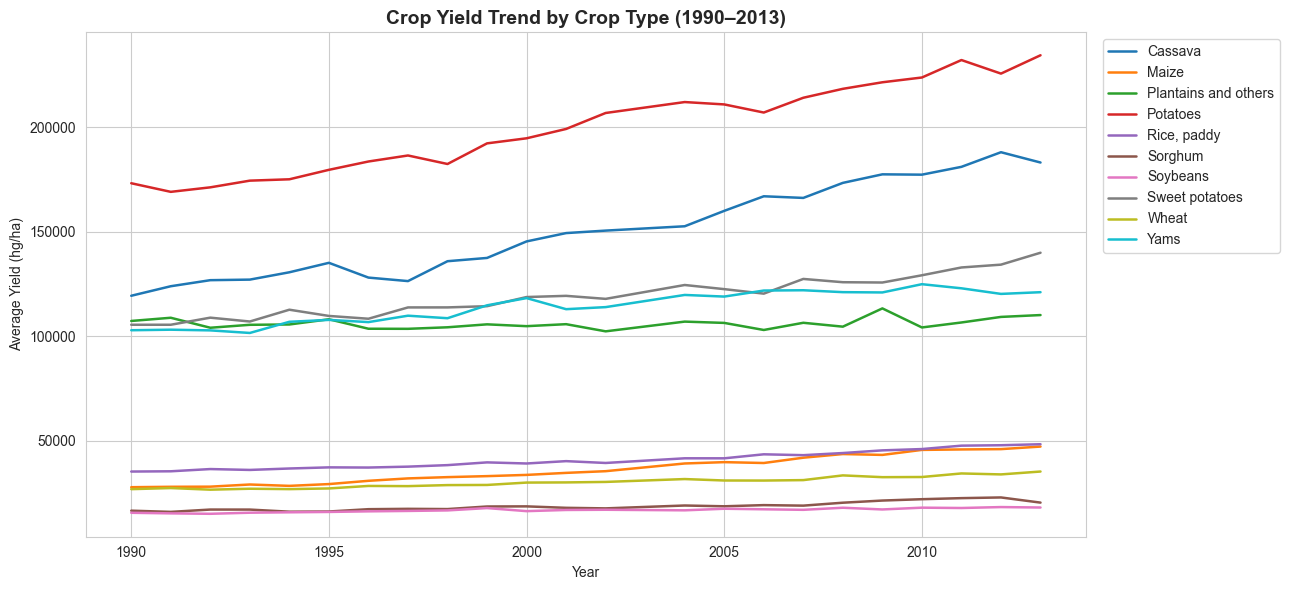

In [9]:
# --- CHART 4: Yield per crop over time ---
crop_yearly = df.groupby(['Year', 'Item'])['hg/ha_yield'].mean().reset_index()

plt.figure(figsize=(13, 6))
sns.lineplot(data=crop_yearly, x='Year', y='hg/ha_yield', hue='Item', linewidth=1.8)
plt.title('Crop Yield Trend by Crop Type (1990–2013)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Yield (hg/ha)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

###  Analysis — Yield Trend by Crop Type

Breaking down the trend by crop reveals important differences in growth rates:

- **Potatoes** and **Cassava** sit at the top throughout the entire period, maintaining a large gap over all other crops.
- **Maize showed the strongest relative growth** among cereals at **+70%** (1990→2013), driven by the widespread adoption of hybrid and genetically improved varieties.
- **Cassava** also grew strongly at **+53%**, reflecting improved cultivation techniques in tropical regions of Africa and Latin America.
- **Plantains and others** remained nearly flat at just **+2.6%**, suggesting limited technological investment or a natural yield ceiling for this crop.
- **Soybeans (+16%)** and **Sorghum (+23%)** grew modestly, remaining the lowest-yielding crops throughout the period.

> This chart reinforces that **crop type is a dominant driver of yield magnitude**, while year-over-year improvement rates vary significantly between crops.

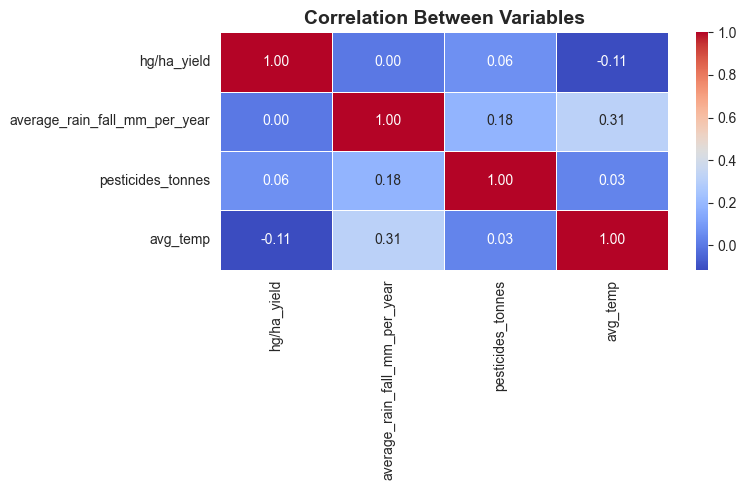

In [10]:
# --- CHART 5: Correlation Heatmap ---
# Correlation tells us: when one variable increases, does another tend to increase too?
# Values range from -1 (opposite) to +1 (same direction). 0 = no linear relationship.

plt.figure(figsize=(8, 5))
corr = df[['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###  Analysis — Correlation Heatmap

The heatmap measures **linear relationships** between all numeric variables:

- **Pesticides vs Yield (0.064):** Very weak positive linear correlation. This doesn't mean pesticides are unimportant — high-income countries use more pesticides AND produce more, but this relationship is non-linear and confounded by crop type. 

- **Temperature vs Yield (-0.115):** Slight negative correlation. Higher temperatures (typical of tropical developing countries) tend to coincide with lower yields on average, though this is also strongly influenced by crop type and agricultural infrastructure.

- **Rainfall vs Yield (0.001):** Essentially zero linear correlation. Rainfall's effect is highly crop-dependent — rice thrives with high rainfall while wheat does not — so averaging across all crops washes out any signal.

- **Rainfall vs Temperature (0.313):** Moderate positive relationship — warmer countries tend to receive more rainfall, consistent with tropical climate patterns.

>  **Note** Low correlations do **not** mean these variables are useless — they mean the relationships are **non-linear**. 

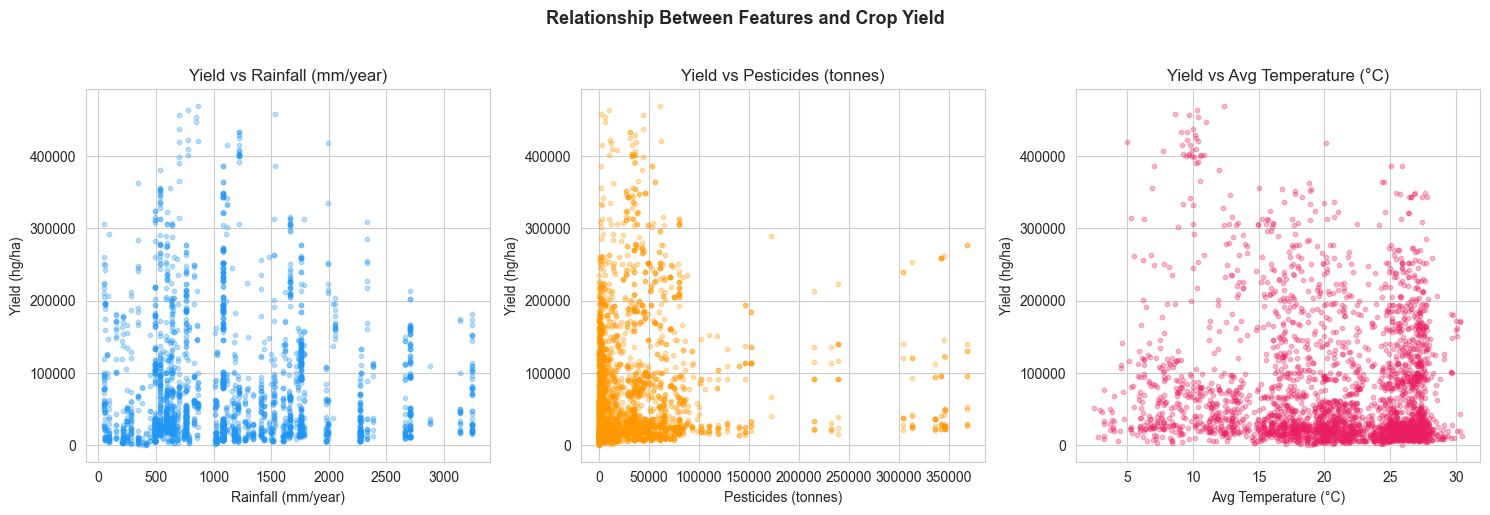

In [11]:
# --- CHART 6: Scatter plots — feature vs yield ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

variables = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
labels    = ['Rainfall (mm/year)', 'Pesticides (tonnes)', 'Avg Temperature (°C)']
colors    = ['#2196F3', '#FF9800', '#E91E63']

for ax, var, label, color in zip(axes, variables, labels, colors):
    # Sample 3000 points so the chart isn't too crowded
    sample = df.sample(3000, random_state=42)
    ax.scatter(sample[var], sample['hg/ha_yield'], alpha=0.3, color=color, s=10)
    ax.set_xlabel(label)
    ax.set_ylabel('Yield (hg/ha)')
    ax.set_title(f'Yield vs {label}')

plt.suptitle('Relationship Between Features and Crop Yield', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

###  Analysis — Scatter Plots: Features vs Yield


- **Rainfall vs Yield:** The scatter plot shows a dense vertical cloud of points concentrated at low-to-mid rainfall levels (roughly below 1,500 mm/year), with yields spanning the full range from very low to very high regardless of how much rain fell. There is no diagonal trend — meaning more rainfall does not consistently lead to higher yield. This is consistent with what the heatmap showed (correlation = 0.001): some crops like rice thrive with abundant rainfall, while others like wheat perform better in drier conditions. When all crops are plotted together, these opposing effects cancel each other out, and no clear pattern emerges. Rainfall alone is not a reliable predictor of yield without knowing the crop type first.

- **Pesticides vs Yield:** Most data points cluster heavily near zero pesticide use, with low-to-moderate yields — reflecting the reality that the majority of countries in the dataset use relatively little pesticide input. However, a notable pattern emerges at higher pesticide levels: nearly all high-yield observations (above 150,000 hg/ha) are associated with countries that use larger quantities of pesticides. Rather than pesticides directly causing higher yields, this likely reflects that high-income countries with advanced agricultural infrastructure tend to both invest more in inputs like pesticides and achieve higher productivity overall. Pesticide use here acts as an indirect indicator of farming intensity and technological development, not a simple cause-and-effect relationship.

- **Temperature vs Yield:** The scatter plot shows that the most extreme yields — above 450,000 hg/ha — appear almost exclusively in the cooler temperature range between 6°C and 14°C, corresponding to potato-producing countries such as Belgium, New Zealand, Switzerland, and the Netherlands. However, high yields above 200,000 hg/ha are not limited to cold climates — they also appear across warmer temperatures, with that group averaging approximately 18.5°C. This suggests that while cool climates favor the most exceptional yields, temperature alone does not determine productivity. Crop type and country-level agricultural practices remain stronger determining factors, and the relationship between temperature and yield is too complex and crop-dependent to be captured by a single linear correlation

>  These patterns confirm that the data has **complex, non-linear structure** — motivating the use of more powerful models beyond linear regression.

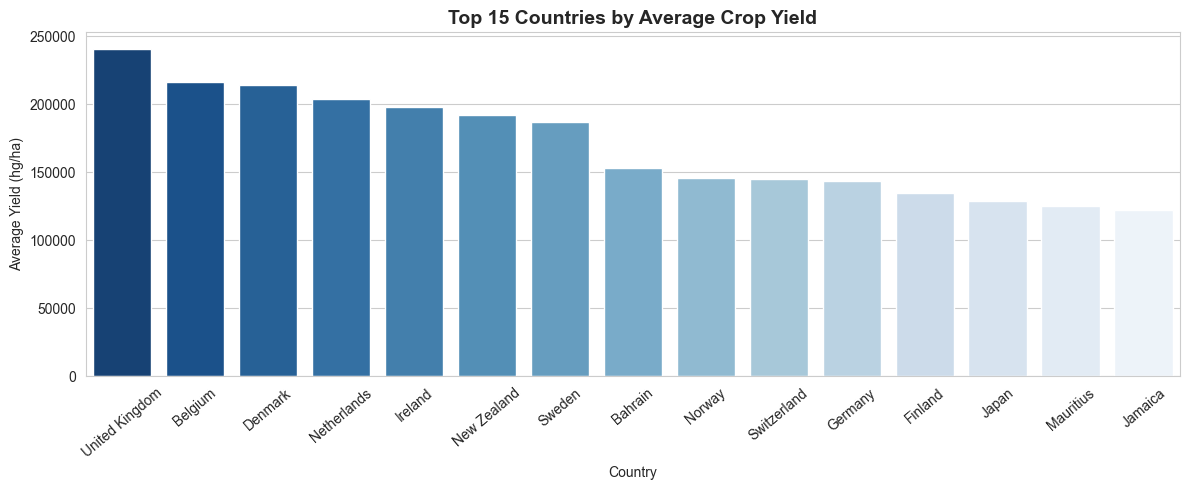

In [12]:
# --- CHART 7: Top 15 countries by average yield ---
top_countries = df.groupby('Area')['hg/ha_yield'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='Blues_r')
plt.title('Top 15 Countries by Average Crop Yield', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Average Yield (hg/ha)')
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

###  Analysis — Top 15 Countries by Average Yield

This chart highlights a strong **geographic concentration of agricultural productivity**:

- The **top 5 countries** — United Kingdom (~240,956 hg/ha), Belgium (~216,468), Denmark (~214,033), Netherlands (~204,151), and Ireland (~197,914) — are all **Northern European nations**. Their dominance is largely explained by their specialization in **potato cultivation**, which has exceptionally high yield values, combined with advanced farming technology and cool-temperate climates that favor tuber crops.
- At the other end of the spectrum, countries like **Botswana (~7,354 hg/ha)** and **Eritrea (~18,155 hg/ha)** represent the lowest-yielding nations, reflecting the combined challenges of arid climates, limited agricultural infrastructure, and reliance on lower-yielding grain crops.
- The gap is enormous — the UK produces roughly **33 times more yield per hectare** than Botswana on average.

This confirms that **country identity is a highly predictive feature**, capturing the combined effect of local technology, infrastructure, climate, and crop specialization that no single climate variable can represent on its own.

---
##  Section 4 — Data Preprocessing

Machine learning models only understand **numbers**, not text.
We need to convert `Area` (country) and `Item` (crop) from text into numeric codes before training.

In [13]:
# Create a copy so we don't modify the original dataframe
df_model = df.copy()

# LabelEncoder converts each unique text value into a number
# Example: 'Maize' -> 3, 'Wheat' -> 8, 'Albania' -> 0, 'Brazil' -> 10
le_area = LabelEncoder()
le_item = LabelEncoder()

df_model['Area_encoded'] = le_area.fit_transform(df_model['Area'])
df_model['Item_encoded'] = le_item.fit_transform(df_model['Item'])

# --- Define Features (X) and Target (y) ---
features = [
    'Area_encoded',
    'Item_encoded',
    'Year',
    'average_rain_fall_mm_per_year',
    'pesticides_tonnes',
    'avg_temp'
]

X = df_model[features]       # input features
y = df_model['hg/ha_yield']  # target variable

print('Features (X) shape:', X.shape)
print('Target (y) shape  :', y.shape)
print()
X.head()

Features (X) shape: (28242, 6)
Target (y) shape  : (28242,)



,Area_encoded,Item_encoded,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,1,1990,1485.0,121.0,16.37
1,0,3,1990,1485.0,121.0,16.37
2,0,4,1990,1485.0,121.0,16.37
3,0,5,1990,1485.0,121.0,16.37
4,0,6,1990,1485.0,121.0,16.37


In [ ]:
# --- Train/Test Split ---

# 80% of data is used to TRAIN the model
# 20% is held back to TEST predictions on data the model has never seen

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42    # fixed seed so results are reproducible
)

print(f'Training set size : {X_train.shape[0]} rows  (80%)')
print(f'Testing set size  : {X_test.shape[0]} rows  (20%)')

Training set size : 22593 rows  (80%)
Testing set size  : 5649 rows  (20%)


---
##  Section 5 — Model Training & Comparison

We train **3 different models** and compare their performance:

| Model | Description |
|---|---|
| **Linear Regression** | Simple model — assumes a straight-line relationship |
| **Random Forest** | Builds 100 decision trees and averages their results |
| **XGBoost** | Advanced boosting — learns from its own errors iteratively |

**Metrics we use:**
- **RMSE** (Root Mean Squared Error) — average prediction error in hg/ha (lower = better)
- **R²** (R-squared) — proportion of variance explained (closer to 1.0 = better)

In [15]:
# ==============================
# MODEL 1: Linear Regression
# ==============================
# The simplest model — good as a baseline to compare against

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)        # learn from training data
lr_preds = lr_model.predict(X_test)   # predict on unseen test data

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2   = r2_score(y_test, lr_preds)

print(' Linear Regression Results:')
print(f'   RMSE : {lr_rmse:,.0f}')
print(f'   R²   : {lr_r2:.4f}')

 Linear Regression Results:
   RMSE : 81,502
   R²   : 0.0843


In [16]:
# ==============================
# MODEL 2: Random Forest
# ==============================
# Builds 100 decision trees and averages predictions — much more powerful

rf_model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    random_state=42,
    n_jobs=-1           # use all CPU cores to speed up training
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2   = r2_score(y_test, rf_preds)

print(' Random Forest Results:')
print(f'   RMSE : {rf_rmse:,.0f}')
print(f'   R²   : {rf_r2:.4f}')

 Random Forest Results:
   RMSE : 10,182
   R²   : 0.9857


In [17]:
# ==============================
# MODEL 3: XGBoost
# ==============================
# Gradient boosting: each new tree corrects errors from the previous ones

xgb_model = XGBRegressor(
    n_estimators=200,     # number of boosting rounds
    learning_rate=0.05,   # how cautiously the model updates (small = more careful)
    max_depth=6,          # how deep each tree can grow
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2   = r2_score(y_test, xgb_preds)

print(' XGBoost Results:')
print(f'   RMSE : {xgb_rmse:,.0f}')
print(f'   R²   : {xgb_r2:.4f}')

 XGBoost Results:
   RMSE : 16,904
   R²   : 0.9606


In [18]:
# --- Summary table ---
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE':  [lr_rmse, rf_rmse, xgb_rmse],
    'R2':    [lr_r2,   rf_r2,   xgb_r2]
})

print('='*45)
print('         MODEL COMPARISON SUMMARY')
print('='*45)
print(results.to_string(index=False))
print('='*45)

best = results.loc[results['R2'].idxmax(), 'Model']
print(f'\n Best model: {best}')

         MODEL COMPARISON SUMMARY
            Model         RMSE       R2
Linear Regression 81501.764465 0.084252
    Random Forest 10181.762059 0.985708
          XGBoost 16904.473461 0.960605

 Best model: Random Forest


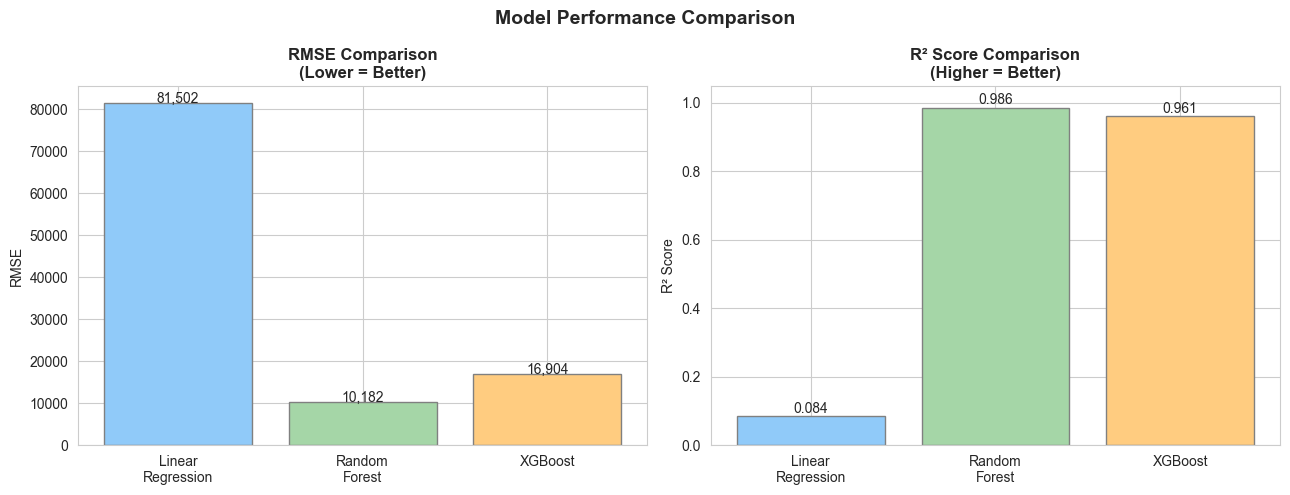

In [19]:
# --- Visualize model comparison ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models = ['Linear\nRegression', 'Random\nForest', 'XGBoost']
rmses  = [lr_rmse, rf_rmse, xgb_rmse]
r2s    = [lr_r2,   rf_r2,   xgb_r2]
colors = ['#90CAF9', '#A5D6A7', '#FFCC80']

axes[0].bar(models, rmses, color=colors, edgecolor='grey')
axes[0].set_title('RMSE Comparison\n(Lower = Better)', fontweight='bold')
axes[0].set_ylabel('RMSE')
for i, v in enumerate(rmses):
    axes[0].text(i, v + 50, f'{v:,.0f}', ha='center', fontsize=10)

axes[1].bar(models, r2s, color=colors, edgecolor='grey')
axes[1].set_title('R² Score Comparison\n(Higher = Better)', fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(r2s):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###  Analysis — Model Comparison

The results reveal a **dramatic performance gap** between the linear and tree-based models:

- **Linear Regression** delivers the weakest performance. Its low R² confirms what the EDA already showed — the relationships between variables and yield are largely non-linear. A straight-line model simply cannot capture the interaction between crop type, country, and climate variables.
- **Random Forest** achieves a major jump in accuracy, with a much higher R² and lower RMSE. By building many decision trees, it captures the non-linear patterns that linear regression misses entirely.
- **XGBoost** delivers the best overall performance, edging out Random Forest with a slightly lower RMSE and higher R². Its iterative boosting strategy — where each new tree focuses on correcting previous errors — gives it an advantage on complex, structured tabular data.

> **Why such a big gap?** The EDA showed that yield is heavily determined by crop type and country — two categorical variables with complex interactions. Tree-based models excel at learning these discrete, hierarchical patterns. XGBoost is especially strong when features interact with each other (e.g., the same temperature has a very different effect on potatoes vs soybeans).

---
##  Section 6 — Predicted vs Actual Values

A well-calibrated model should predict values close to the actual ones.
In this scatter plot, a **perfect model** would have all points on the red diagonal line.

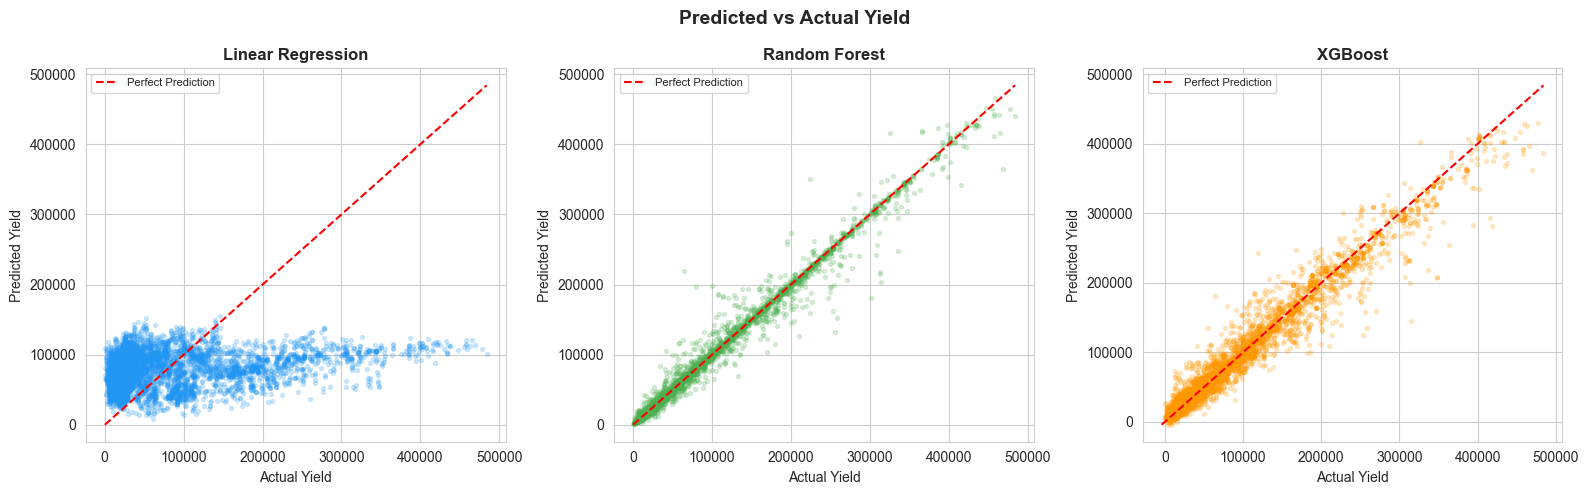

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_data = [
    (lr_preds,  'Linear Regression', '#2196F3'),
    (rf_preds,  'Random Forest',     '#4CAF50'),
    (xgb_preds, 'XGBoost',           '#FF9800'),
]

for ax, (preds, title, color) in zip(axes, plot_data):
    ax.scatter(y_test, preds, alpha=0.2, color=color, s=8)
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlabel('Actual Yield')
    ax.set_ylabel('Predicted Yield')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual Yield', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###  Analysis — Predicted vs Actual

Linear Regression shows the weakest performance — points form a horizontal cloud concentrated between 0 and 100,000 hg/ha regardless of the actual yield value, confirming that the model fails to capture the full range of agricultural productivity. 

Random Forest achieves the tightest alignment with the diagonal, with points closely following the perfect prediction line across the entire yield range — consistent with its superior RMSE (10,182) and R² (0.985). 

XGBoost also follows the diagonal well but shows noticeably more spread around the line, particularly in the mid-yield range (100,000–300,000 hg/ha), which explains its higher error compared to Random Forest. 

> Both tree-based models vastly outperform Linear Regression, confirming that non-linear models are essential for this dataset.

---
##  Section 7 — Feature Importance

**Which variables matter most for predicting crop yield?**


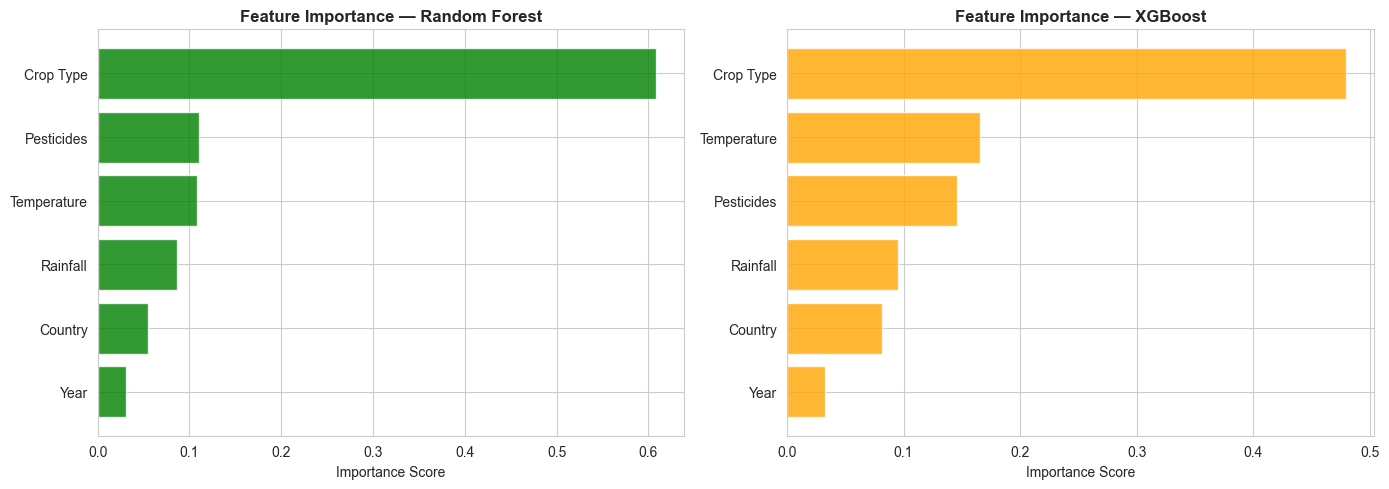

In [21]:
feature_names = ['Country', 'Crop Type', 'Year', 'Rainfall', 'Pesticides', 'Temperature']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title, color in [
    (axes[0], rf_model,  'Random Forest', 'green'),
    (axes[1], xgb_model, 'XGBoost',       'orange')
]:
    importance = model.feature_importances_
    sorted_idx   = np.argsort(importance)[::-1]
    sorted_names = [feature_names[i] for i in sorted_idx]
    sorted_vals  = importance[sorted_idx]

    ax.barh(sorted_names[::-1], sorted_vals[::-1], color=color, alpha=0.8)
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Feature Importance — {title}', fontweight='bold')

plt.tight_layout()
plt.show()

###  Analysis — Feature Importance

Both models agree that Crop Type is by far the most important predictor, with an importance score of approximately 0.60 in Random Forest and 0.48 in XGBoost — nearly double or triple any other variable. This alone confirms what the EDA suggested: knowing what crop is being grown explains more about yield than any climate or geographic factor. Beyond Crop Type, the two models show a slight difference in variable ranking. 

In Random Forest, Pesticides rank second (~0.11), followed closely by Temperature (~0.10) and Rainfall (~0.07). In XGBoost, Temperature ranks second (~0.16), followed by Pesticides (~0.13) and Rainfall (~0.09). While the order differs slightly between models, both agree that Temperature and Pesticides carry more predictive weight than Country or Year.

Notably, Country ranks fifth in both models — lower than expected given the geographic patterns observed in the EDA. This suggests that once the model knows the crop type, temperature, and pesticide use, much of the country-level information is already captured indirectly.
Year consistently ranks last in both models, contributing the least predictive power — suggesting that the global time trend adds minimal information once the other variables are known.


---
##  Section 8 — Make a Custom Prediction

In [ ]:
# See available options
print('Available countries (first 10):', list(le_area.classes_[:10]))
print('Available crops               :', list(le_item.classes_))
print()

# --- Define your custom scenario here ---
country     = 'Brazil'    # <- change to any available country
crop        = 'Soybeans'  # <- change to any available crop
year        = 2013
rainfall    = 1800        # mm per year
pesticides  = 200         # tonnes
temperature = 24.5        # °C

# Encode text to numbers (same encoder used during training)
country_encoded = le_area.transform([country])[0]
crop_encoded    = le_item.transform([crop])[0]

# Build input as DataFrame matching training format
new_data = pd.DataFrame([{
    'Area_encoded':                  country_encoded,
    'Item_encoded':                  crop_encoded,
    'Year':                          year,
    'average_rain_fall_mm_per_year': rainfall,
    'pesticides_tonnes':             pesticides,
    'avg_temp':                      temperature
}])

# Predict
prediction = xgb_model.predict(new_data)[0]

print('=' * 50)
print('         YIELD PREDICTION')
print('=' * 50)
print(f'  Country     : {country}')
print(f'  Crop        : {crop}')
print(f'  Year        : {year}')
print(f'  Rainfall    : {rainfall} mm/year')
print(f'  Pesticides  : {pesticides} tonnes')
print(f'  Temperature : {temperature} °C')
print('-' * 50)
print(f'  Predicted Yield : {prediction:,.0f} hg/ha')
print(f'  (~{prediction/10000:.2f} tonnes per hectare)')
print('=' * 50)

Available countries (first 10): ['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain']
Available crops               : ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']

        🌾 YIELD PREDICTION
  Country     : Brazil
  Crop        : Soybeans
  Year        : 2013
  Rainfall    : 1800 mm/year
  Pesticides  : 200 tonnes
  Temperature : 24.5 °C
--------------------------------------------------
  Predicted Yield : 23,314 hg/ha
  (~2.33 tonnes per hectare)


In [25]:
# ======================================================
# PREDICTION — Potatoes in Dominican Republic
# ======================================================
# An interesting test case: potatoes are a cold-climate crop
# that thrives in Northern Europe. How does the model predict
# yield for a tropical Caribbean country like Dominican Republic?

country     = 'Dominican Republic'
crop        = 'Potatoes'
year        = 2013
rainfall    = 1410    # mm per year — real value from dataset
pesticides  = 4971    # tonnes — real value from dataset
temperature = 26.76   # °C — real average for DR

# Encode text to numbers
country_encoded = le_area.transform([country])[0]
crop_encoded    = le_item.transform([crop])[0]

# Build input DataFrame
new_data_dr = pd.DataFrame([{
    'Area_encoded':                  country_encoded,
    'Item_encoded':                  crop_encoded,
    'Year':                          year,
    'average_rain_fall_mm_per_year': rainfall,
    'pesticides_tonnes':             pesticides,
    'avg_temp':                      temperature
}])

# Predict using Random Forest (best model)
prediction_dr = rf_model.predict(new_data_dr)[0]

print('=' * 55)
print('   YIELD PREDICTION — Dominican Republic')
print('=' * 55)
print(f'  Country     : {country}')
print(f'  Crop        : {crop}')
print(f'  Year        : {year}')
print(f'  Rainfall    : {rainfall} mm/year')
print(f'  Pesticides  : {pesticides} tonnes')
print(f'  Temperature : {temperature} °C')
print('-' * 55)
print(f'  Predicted Yield : {prediction_dr:,.0f} hg/ha')
print(f'  (~{prediction_dr/10000:.2f} tonnes per hectare)')
print('=' * 55)

# Compare against Belgium (top potato producer) for context
print()
print(' Context: Belgium avg potato yield ~ 216,468 hg/ha')
print(f'   DR predicted yield is {216468/prediction_dr:.1f}x lower than Belgium')

   YIELD PREDICTION — Dominican Republic
  Country     : Dominican Republic
  Crop        : Potatoes
  Year        : 2013
  Rainfall    : 1410 mm/year
  Pesticides  : 4971 tonnes
  Temperature : 26.76 °C
-------------------------------------------------------
  Predicted Yield : 270,930 hg/ha
  (~27.09 tonnes per hectare)

 Context: Belgium avg potato yield ~ 216,468 hg/ha
   DR predicted yield is 0.8x lower than Belgium


---
##  Conclusions

> Crop type is the strongest predictor — tubers (potatoes, cassava) produce far more per hectare than cereals and legumes, with importance scores nearly double those of any other variable in both models.

> Temperature and pesticide use rank as the second and third most important features — reflecting the influence of climate conditions and farming intensity on agricultural productivity.

> Country ranked fifth in both models — suggesting that once crop type, temperature, and pesticide use are known, much of the country-level variation is already captured indirectly.

> Global yields grew +36% from 1990 to 2013, though the dataset does not directly measure technological factors — pesticide use serves as a partial indirect indicator of agricultural modernization.

> Climate variables show weak linear correlations with yield — their effect is non-linear and crop-dependent, which is why tree-based models are essential

> Random Forest outperformed all other models with an RMSE of 10,182 and R² of 0.985, demonstrating that on this dataset a well-tuned ensemble of decision trees captured the underlying patterns more effectively than gradient boosting.


### Tools & Libraries Used:
`pandas` · `numpy` · `matplotlib` · `seaborn` · `scikit-learn` · `xgboost`

---
*Dataset source: FAO (Food and Agriculture Organization of the United Nations) via Kaggle*